<a href="https://colab.research.google.com/github/KARTHIII023/EXIT-EXAM-/blob/main/exit_exam_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 1

In [629]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [630]:
g2 = pd.read_csv("/content/G2.csv")

In [631]:
g2.shape

(1351, 10)

In [632]:
g2.head(10)

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83
3,4,charmander,6,85,62.0,fire,NaN,39,52,43
4,5,charmeleon,11,190,142.0,fire,NaN,58,64,58
5,6,charizard,17,905,240.0,fire,flying,78,84,78
6,7,squirtle,5,90,63.0,water,NaN,44,48,65
7,8,wartortle,10,225,142.0,water,NaN,59,63,80
8,9,blastoise,16,855,239.0,water,NaN,79,83,100
9,10,caterpie,3,29,39.0,bug,NaN,45,30,35


In [633]:
print(g2.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1351 non-null   int64  
 1   name             1351 non-null   object 
 2   height_dm        1351 non-null   int64  
 3   weight_hg        1351 non-null   int64  
 4   base_experience  1302 non-null   float64
 5   type_1           1351 non-null   object 
 6   type_2           765 non-null    object 
 7   hp               1351 non-null   int64  
 8   attack           1351 non-null   int64  
 9   defense          1351 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 105.7+ KB
None


In [634]:
print(g2.describe())


                 id    height_dm     weight_hg  base_experience           hp  \
count   1351.000000  1351.000000   1351.000000      1302.000000  1351.000000   
mean    2841.692080    20.443375    991.059956       161.943932    71.673575   
std     4139.019112    53.238467   1953.115812        82.532554    26.827529   
min        1.000000     1.000000      0.000000        36.000000     1.000000   
25%      338.500000     6.000000     94.500000        71.000000    55.000000   
50%      676.000000    11.000000    326.000000       165.000000    70.000000   
75%     1013.500000    17.000000    853.500000       222.500000    85.000000   
max    10326.000000  1000.000000  10000.000000       608.000000   255.000000   

            attack      defense  
count  1351.000000  1351.000000  
mean     82.757957    76.193930  
std      32.351906    30.712902  
min       5.000000     5.000000  
25%      60.000000    55.000000  
50%      80.000000    70.000000  
75%     102.500000    95.000000  
max    

In [635]:
print(g2.columns)


Index(['id', 'name', 'height_dm', 'weight_hg', 'base_experience', 'type_1',
       'type_2', 'hp', 'attack', 'defense'],
      dtype='object')


In [636]:
numeric_columns = g2.select_dtypes(include=np.number).columns
print(numeric_columns)

Index(['id', 'height_dm', 'weight_hg', 'base_experience', 'hp', 'attack',
       'defense'],
      dtype='object')


In [637]:
categorical_columns = g2.select_dtypes(include="object").columns
print(categorical_columns)

Index(['name', 'type_1', 'type_2'], dtype='object')


In [638]:
print(g2.isnull().sum())

id                   0
name                 0
height_dm            0
weight_hg            0
base_experience     49
type_1               0
type_2             586
hp                   0
attack               0
defense              0
dtype: int64


In [639]:
print("Duplicate rows:", g2.duplicated().sum())

Duplicate rows: 0


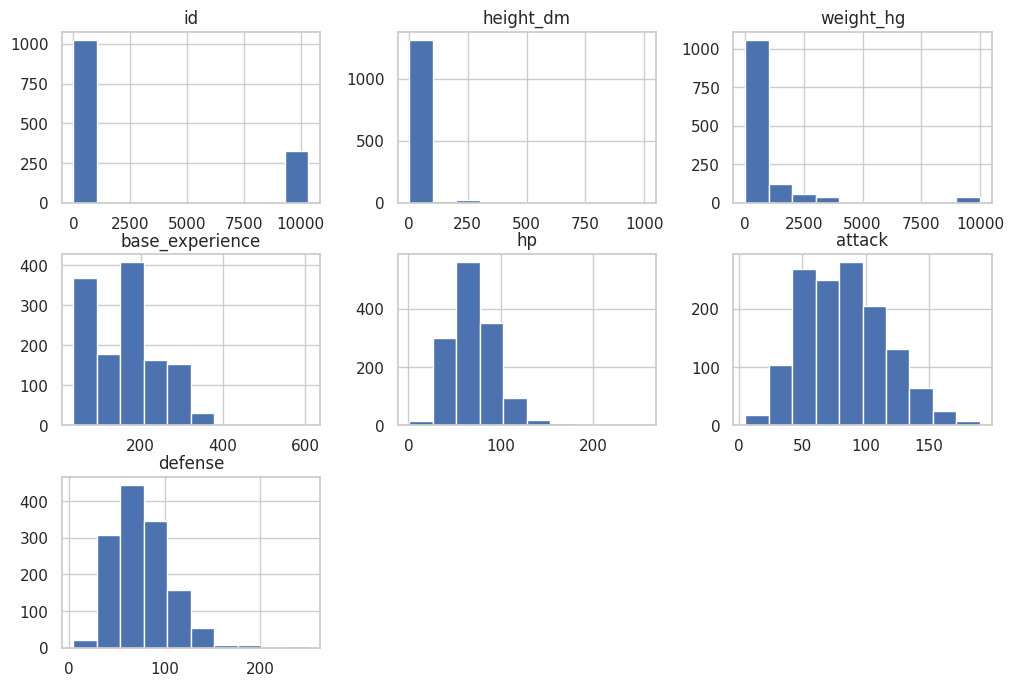

In [640]:

g2.hist(figsize=(12, 8))
plt.show()

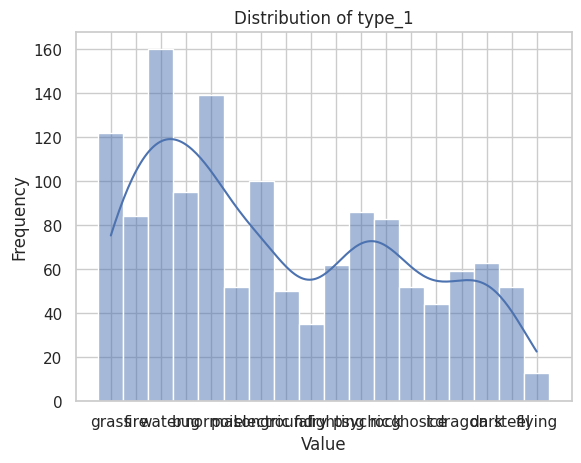

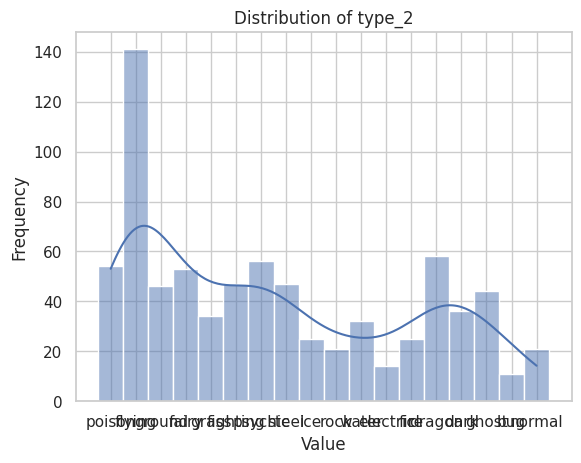

In [641]:


sns.histplot(data=g2, x="type_1", kde=True)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of type_1")
plt.show()
sns.histplot(data=g2, x="type_2", kde=True)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of type_2")
plt.show()

In [642]:

type_counts = g2["type_1"].value_counts()

print(type_counts)

type_1
water       160
normal      139
grass       122
electric    100
bug          95
psychic      86
fire         84
rock         83
dark         63
fighting     62
dragon       59
steel        52
poison       52
ghost        52
ground       50
ice          44
fairy        35
flying       13
Name: count, dtype: int64


THE MOST APPEARING POKEMON TYPE IS WATER

In [643]:
variation = g2[numeric_columns].std().sort_values(ascending=False)

print(variation)
print("Column with greatest variation:", variation.idxmax())

id                 4139.019112
weight_hg          1953.115812
base_experience      82.532554
height_dm            53.238467
attack               32.351906
defense              30.712902
hp                   26.827529
dtype: float64
Column with greatest variation: id


ID AND WEIGHT SHOWS THE GREATEST VARIATION AMONG POKEMON

THE INITIAL OBSERVATION OF THE DATSET IS THAT IT CONTAIN (1351, 10) ROWS AND COLUMNS WITH ALMOST EVERTHING RIGHT SKEWED AND IN NORMAL DISTRIBUTION AND THE TARGET VARIABLE IS TYPE 1

# **TASK 2**

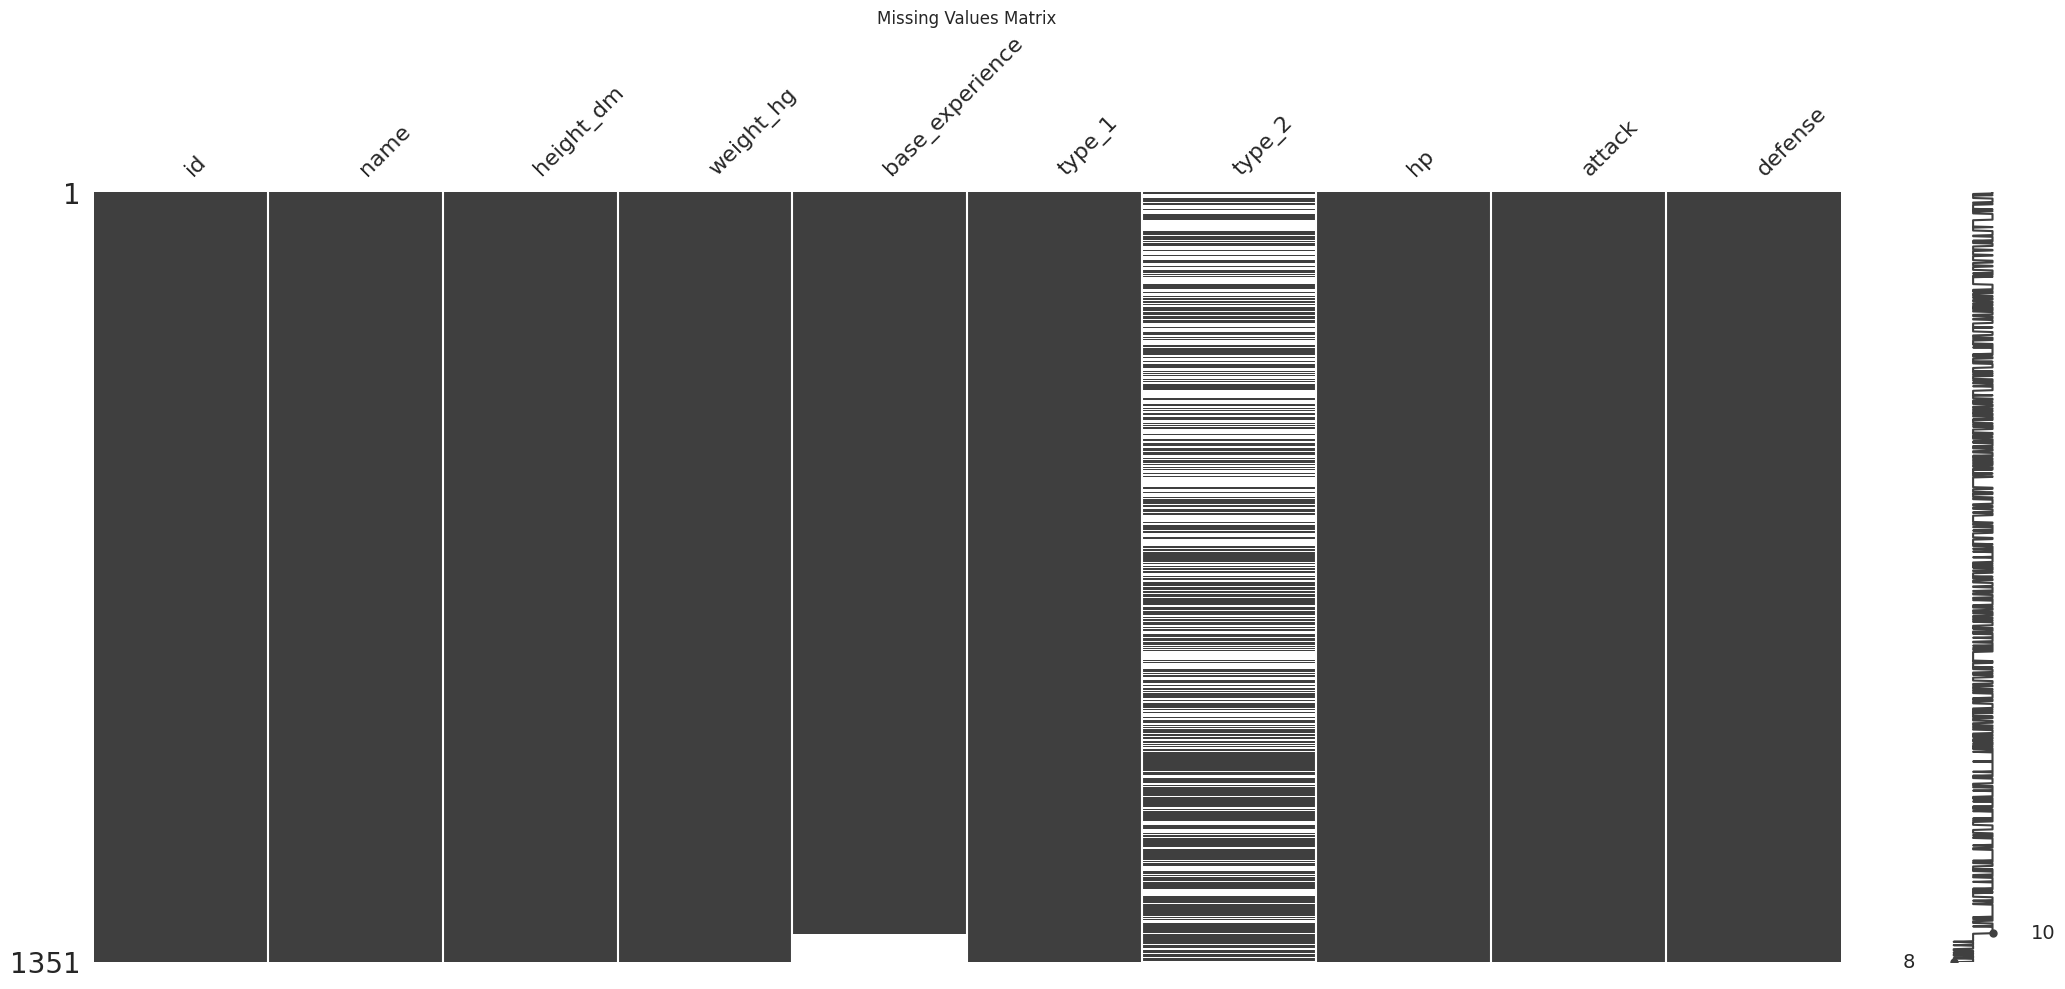

In [644]:

import missingno as msno
msno.matrix(g2)

plt.title("Missing Values Matrix")
plt.show()

In [645]:
g2["base_experience"] = g2["base_experience"].fillna(g2["base_experience"].median())

In [646]:
g2 = g2.drop(columns=["id"])

In [647]:
print(g2.isnull().sum())

name                 0
height_dm            0
weight_hg            0
base_experience      0
type_1               0
type_2             586
hp                   0
attack               0
defense              0
dtype: int64


In [648]:
g2.head()

,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,bulbasaur,7,69,64.0,grass,poison,45,49,49
1,ivysaur,10,130,142.0,grass,poison,60,62,63
2,venusaur,20,1000,236.0,grass,poison,80,82,83
3,charmander,6,85,62.0,fire,NaN,39,52,43
4,charmeleon,11,190,142.0,fire,NaN,58,64,58


In [649]:
g2 = g2.drop(columns=["name"])

In [650]:
g2["type_2"] = g2["type_2"].fillna(g2["type_2"].mode()[0])

In [651]:


g2 = pd.get_dummies(
    g2,
    columns=["type_2"],
    drop_first=True,
    dtype=int
)

In [652]:
g2.head()

,height_dm,weight_hg,base_experience,type_1,hp,attack,defense,type_2_dark,type_2_dragon,type_2_electric,...,type_2_ghost,type_2_grass,type_2_ground,type_2_ice,type_2_normal,type_2_poison,type_2_psychic,type_2_rock,type_2_steel,type_2_water
0,7,69,64.0,grass,45,49,49,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,10,130,142.0,grass,60,62,63,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,20,1000,236.0,grass,80,82,83,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,6,85,62.0,fire,39,52,43,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,11,190,142.0,fire,58,64,58,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [653]:

from sklearn.model_selection import train_test_split

X = g2.drop("type_1", axis=1)
y = g2["type_1"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


Preprocessing is important because it convert  raw  data into  meaningful one so a ML model can use it correctly and learn meaningful patterns to predict.

TYPE 2 contain 500+ mising value can be filled usually with mode but can  droped type 2 as it is not being given in as input later  so might mislead the prediction

# TASK 3

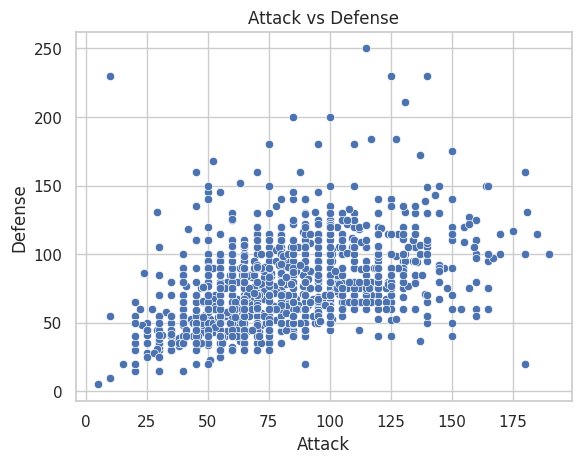

In [654]:
sns.scatterplot(
    data=g2,
    x="attack",
    y="defense"
)

plt.title("Attack vs Defense")
plt.xlabel("Attack")
plt.ylabel("Defense")
plt.show()

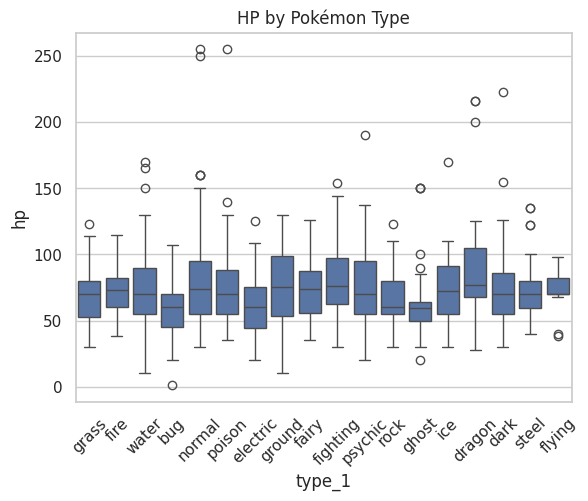

In [655]:
sns.boxplot(data=g2, x="type_1", y="hp")
plt.title("HP by Pokémon Type")
plt.xticks(rotation=45)
plt.show()

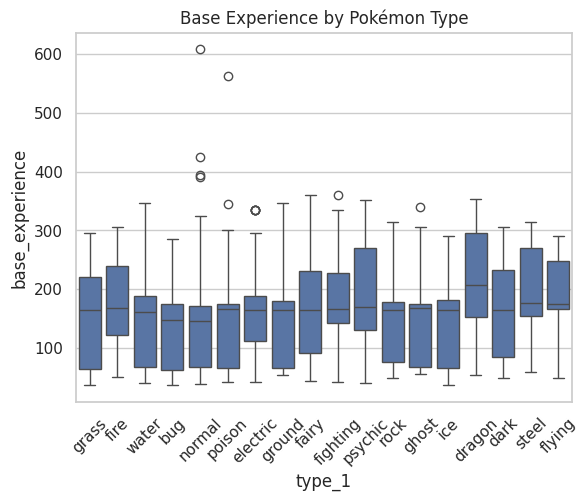

In [656]:
sns.boxplot(data=g2, x="type_1", y="base_experience")
plt.title("Base Experience by Pokémon Type")
plt.xticks(rotation=45)
plt.show()

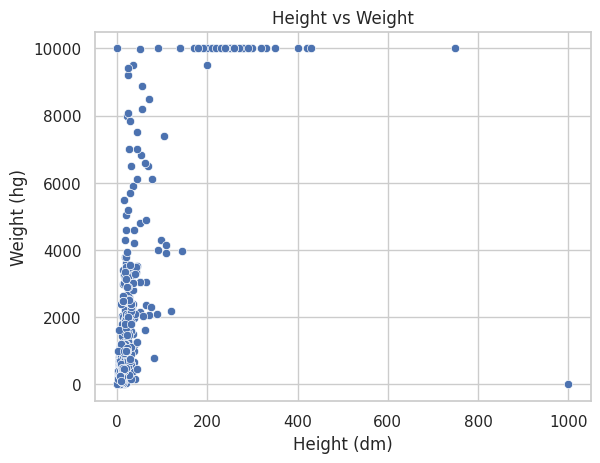

In [657]:
sns.scatterplot(data=g2, x="height_dm", y="weight_hg")
plt.title("Height vs Weight")
plt.xlabel("Height (dm)")
plt.ylabel("Weight (hg)")
plt.show()

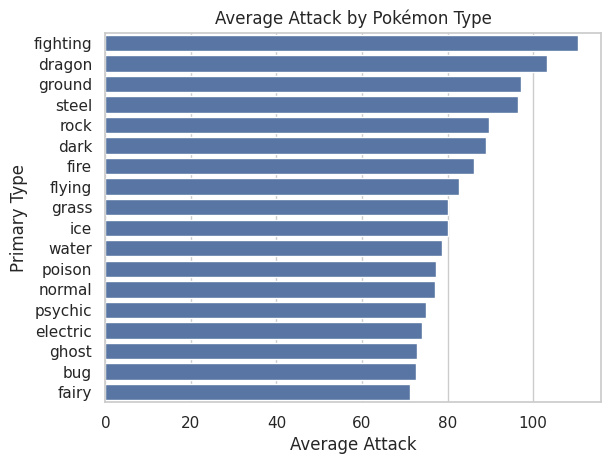

In [658]:

type_attack = g2.groupby("type_1")["attack"].mean().sort_values(ascending=False)

sns.barplot(
    x=type_attack.values,
    y=type_attack.index,
    orient="h"
)

plt.title("Average Attack by Pokémon Type")
plt.xlabel("Average Attack")
plt.ylabel("Primary Type")
plt.show()

THE FIGHTING POKEMON TYPE TENDS TO HAVE THE HIGHEST AVERAGE ATTACK

YES THERE EXIST A RELATIONSHIP BETWEEN HEIGHT AND WEIGHT

THE ATTCK AND DEFENCE MIGHT BE THE MOST USEFUL FOR DISTINGUISHING POKEMON TYPE

# **TASK 4 **

In [659]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model1 = LogisticRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

accuracy1 = accuracy_score(y_test, y_pred1)
print("Logistic Regression Accuracy:", accuracy1)

Logistic Regression Accuracy: 0.14391143911439114


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [660]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

accuracy2 = accuracy_score(y_test, y_pred2)
print("Decision Tree Accuracy:", accuracy2)

Decision Tree Accuracy: 0.2140221402214022


In [661]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

accuracy3 = accuracy_score(y_test, y_pred3)
print("Random Forest Accuracy:", accuracy3)

Random Forest Accuracy: 0.2952029520295203


In [662]:
from sklearn.neighbors import KNeighborsClassifier

model4 = KNeighborsClassifier()
model4.fit(X_train, y_train)

y_pred4 = model4.predict(X_test)

accuracy4 = accuracy_score(y_test, y_pred4)
print("KNN Accuracy:", accuracy4)

KNN Accuracy: 0.16605166051660517


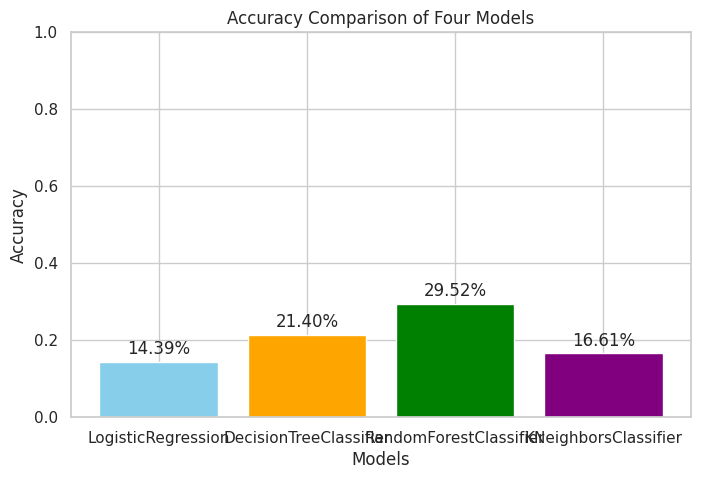

In [663]:

accuracies = [
    accuracy1,
    accuracy2,
    accuracy3,
    accuracy4
]

model_names = [
    "LogisticRegression",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "KNeighborsClassifier"
]

plt.figure(figsize=(8, 5))

bars = plt.bar(model_names, accuracies, color=["skyblue", "orange", "green", "purple"])

plt.title("Accuracy Comparison of Four Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{accuracy:.2%}",
        ha="center"
    )

plt.show()

weight_hg          0.160285
base_experience    0.156885
attack             0.145938
defense            0.142826
hp                 0.139630
height_dm          0.125465
type_2_flying      0.020007
type_2_fairy       0.009469
type_2_dragon      0.009194
type_2_steel       0.008468
type_2_psychic     0.008320
type_2_poison      0.008160
type_2_grass       0.007893
type_2_ghost       0.007729
type_2_ground      0.007216
type_2_water       0.006933
type_2_fighting    0.006796
type_2_fire        0.006133
type_2_dark        0.005729
type_2_ice         0.004843
type_2_normal      0.004547
type_2_rock        0.004113
type_2_electric    0.003421
dtype: float64


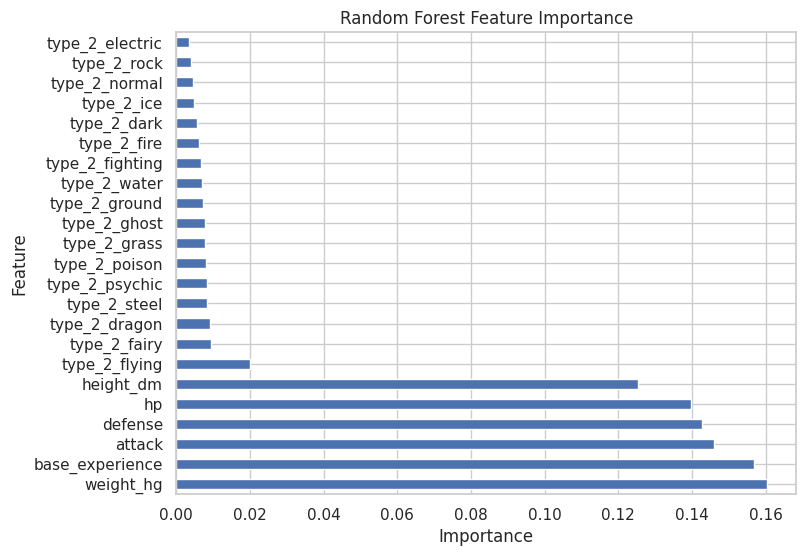

In [664]:

feature_importance = pd.Series(
    model3.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

feature_importance.plot(kind="barh", figsize=(8, 6))
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

RANDOM FOREST CLASSIFIER MODEL ACHIEVED THE BEST PERFORMANCE

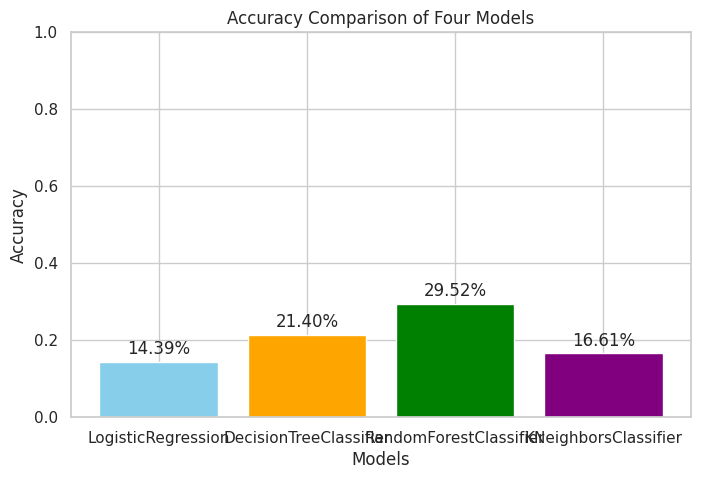

In [676]:

accuracies = [
    accuracy1,
    accuracy2,
    accuracy3,
    accuracy4
]

model_names = [
    "LogisticRegression",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "KNeighborsClassifier"
]

plt.figure(figsize=(8, 5))

bars = plt.bar(model_names, accuracies, color=["skyblue", "orange", "green", "purple"])

plt.title("Accuracy Comparison of Four Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{accuracy:.2%}",
        ha="center"
    )

plt.show()

In [666]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred3, labels=labels)

misclassified = cm.copy()

np.fill_diagonal(misclassified, 0)

misclassified_counts = pd.Series(
    misclassified.sum(axis=1),
    index=labels
).sort_values(ascending=False)

print(misclassified_counts)

print(
    "Most frequently misclassified type:",
    misclassified_counts.idxmax()
)

water       20
fire        17
grass       16
dark        15
fighting    13
bug         12
psychic     12
normal      11
ground      10
steel       10
ice         10
poison       9
electric     8
fairy        8
rock         7
dragon       6
ghost        6
flying       1
dtype: int64
Most frequently misclassified type: water


**Most frequently misclassified type: water**

In [667]:
analysis = X_test.copy()
analysis["actual_type"] = y_test
analysis["predicted_type"] = y_pred3


analysis["correct"] = (
    analysis["actual_type"] == analysis["predicted_type"]
)


type_accuracy = (
    analysis.groupby("actual_type")["correct"]
    .mean()
    .sort_values()
)

print("Accuracy by Pokémon type:")
print(type_accuracy)

print("\nMost difficult type:")
print(type_accuracy.idxmin())

Accuracy by Pokémon type:
actual_type
flying      0.000000
fairy       0.000000
dark        0.062500
poison      0.100000
ice         0.166667
ground      0.166667
fire        0.227273
steel       0.230769
ghost       0.250000
fighting    0.277778
water       0.285714
grass       0.333333
electric    0.333333
psychic     0.333333
bug         0.428571
dragon      0.500000
rock        0.500000
normal      0.500000
Name: correct, dtype: float64

Most difficult type:
flying


In [671]:
from sklearn.model_selection import GridSearchCV


model = RandomForestClassifier(random_state=42)

# Parameters to test
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Grid Search
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [672]:


best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.2952029520295203


# TASK 5

In [674]:
import pickle
with open("models.pkl", "wb") as file:
    pickle.dump(best_model , file)


In [675]:

FEATURE = X.columns.tolist()

with open("feature_columns.pkl", "wb") as file:
    pickle.dump(FEATURE, file)

MY  APPILCATION HELPS GAME DEVELOPERS  AND PLAYERS TO PREDICT EXISTING AND NEW POKEMON CHARACTERS  AND MAKE THE GAME MORE INTERESTING

THE ONLY LIMITATION IS THAT AS THE INPUT FEATURES ARE QUITE INSUFFICIENT AND THE SYSTEM MAY LEAD TO PREDICTION TOWARDS EXISTING POKEMON AS MISTAKE WHICH IS NOT GOOD FOR MY PREDICTION SYSTEM